In [3]:
from google.colab import files

print("Please upload the 'ecommerce_data.csv' file.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please upload the 'ecommerce_data.csv' file.


Saving ecommerce_returns_synthetic_data.csv to ecommerce_returns_synthetic_data (1).csv
User uploaded file "ecommerce_returns_synthetic_data (1).csv" with length 1329832 bytes


In [7]:
import pandas as pd

df = pd.read_csv('ecommerce_returns_synthetic_data (1).csv')
df['Returned'] = df['Return_Date'].notna()
return_rate = df.groupby("Product_Category")["Returned"].mean()
print(return_rate)

Product_Category
Books          0.506614
Clothing       0.524500
Electronics    0.509320
Home           0.490148
Toys           0.495370
Name: Returned, dtype: float64


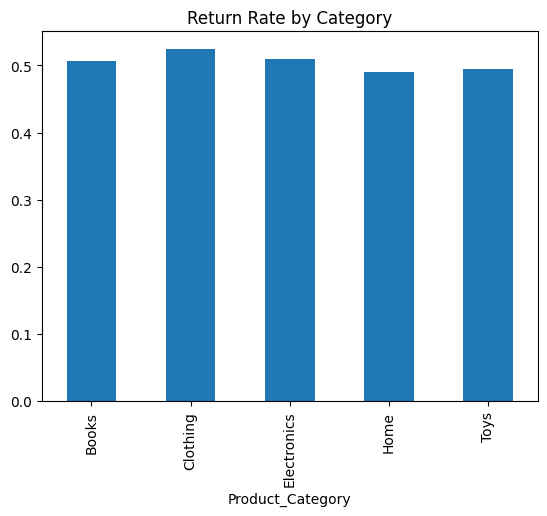

In [9]:
import matplotlib.pyplot as plt

return_rate.plot(kind='bar')
plt.title("Return Rate by Category")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[["Product_Price", "Order_Quantity"]]
y = df["Returned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.4975


In [11]:
print(df.columns)

Index(['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Return_Date',
       'Product_Category', 'Product_Price', 'Order_Quantity', 'Return_Reason',
       'Return_Status', 'Days_to_Return', 'User_Age', 'User_Gender',
       'User_Location', 'Payment_Method', 'Shipping_Method',
       'Discount_Applied', 'Returned'],
      dtype='object')


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[["Price", "Quantity"]]
y = df["Returned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

KeyError: "None of [Index(['Price', 'Quantity'], dtype='object')] are in the [columns]"

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# One-hot encode 'Product_Category'
df_encoded = pd.get_dummies(df, columns=['Product_Category'], drop_first=True)

# Define features (X) including new one-hot encoded columns and existing numerical ones
# Exclude 'Return_Date', 'Returned', and other non-feature columns from X
feature_columns = ['Product_Price', 'Order_Quantity'] + [col for col in df_encoded.columns if 'Product_Category_' in col]
X = df_encoded[feature_columns]
y = df_encoded['Returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_cat = LogisticRegression(max_iter=1000)
model_cat.fit(X_train, y_train)

accuracy_cat = model_cat.score(X_test, y_test)
print("Accuracy with categorical features:", accuracy_cat)

Accuracy with categorical features: 0.5035
